In [1]:
import pandas as pd
import numpy as np

from utils.config import load_config
from preprocessing.house_prices_preprocessing import HousePricesPreprocessor
from models.advanced.regression import run_advanced_regression
from models.advanced.training_history import show_training_history

In [2]:
config = load_config()

data = pd.read_csv(config["paths"]["train"])

# --- разделяем target ---
target = "SalePrice"

# логарифмируем таргет
y = np.log1p(data[target])

X = data.drop(columns=[target])

# --- preprocessing ---
preprocessor = HousePricesPreprocessor(outlier_quantile=0.95)

X_prepared = preprocessor.fit_transform(X)

X_prepared.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageFinish_Unf,GarageFinish_Fin,GarageFinish_None,BsmtFinType1_GLQ,BsmtFinType1_ALQ,BsmtFinType1_Unf,BsmtFinType1_Rec,BsmtFinType1_BLQ,BsmtFinType1_None,BsmtFinType1_LwQ
0,0.073375,-0.208804,-0.332210,0.651479,-0.517200,1.050994,0.878668,0.739648,0.667140,-0.327561,...,0,0,0,1,0,0,0,0,0,0
1,-0.872563,0.646406,-0.009592,-0.071836,2.179628,0.156734,-0.429577,-0.654947,1.327216,-0.327561,...,0,0,0,0,1,0,0,0,0,0
2,0.073375,-0.037762,0.453294,0.651479,-0.517200,0.984752,0.830215,0.497729,0.133255,-0.327561,...,0,0,0,1,0,0,0,0,0,0
3,0.309859,-0.493874,-0.023619,0.651479,-0.517200,-1.863632,-0.720298,-0.654947,-0.521967,-0.327561,...,1,0,0,0,1,0,0,0,0,0
4,0.073375,0.874462,1.297710,1.374795,-0.517200,0.951632,0.733308,1.835402,0.543376,-0.327561,...,0,0,0,1,0,0,0,0,0,0


In [3]:
advanced_results = run_advanced_regression(
    X_prepared,
    y,
    with_history=True,
)

In [4]:
advanced_results['metrics']

,model,MAE,MSE,RMSE,R2
0,CatBoost,0.082382,0.016261,0.127517,0.912863
1,GradientBoosting,0.086479,0.016515,0.128509,0.911503
2,XGBoost,0.086019,0.017592,0.132633,0.905731
3,LightGBM,0.094722,0.020801,0.144224,0.888534
4,Bagging,0.097669,0.021571,0.146869,0.884408
5,ExtraTrees,0.096796,0.021629,0.147069,0.884094
6,RandomForest,0.097221,0.021691,0.147279,0.883764


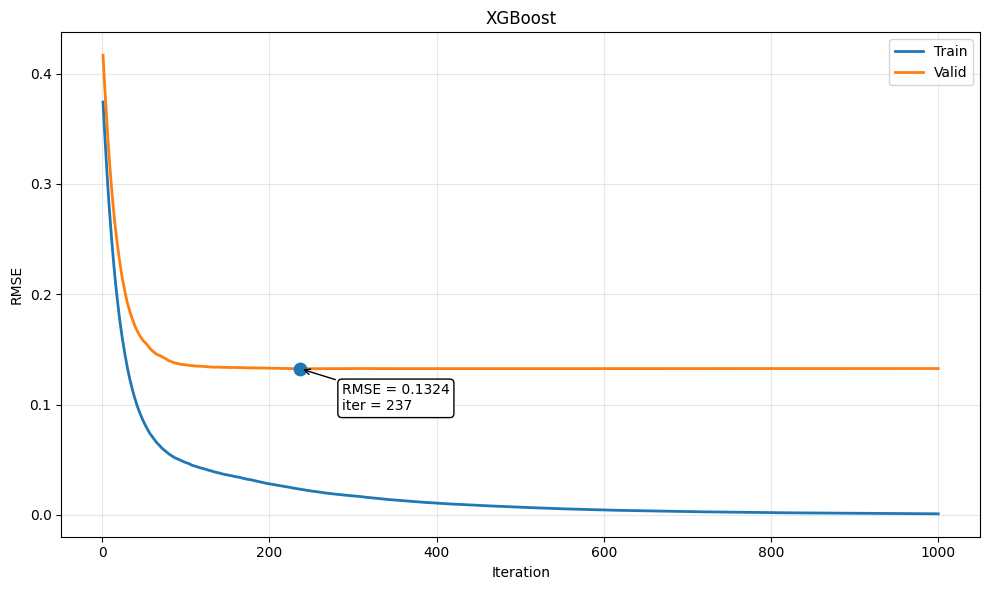

In [5]:
show_training_history(
    advanced_results["training_history"]["XGBoost"],
    model_name="XGBoost",
)

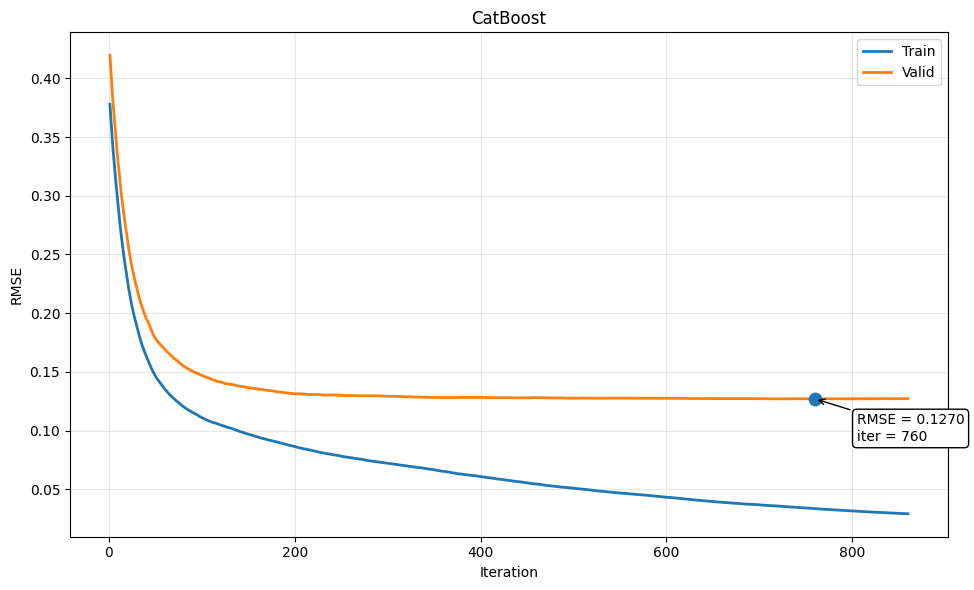

In [6]:
show_training_history(
    advanced_results["training_history"]["CatBoost"],
    model_name="CatBoost",
)

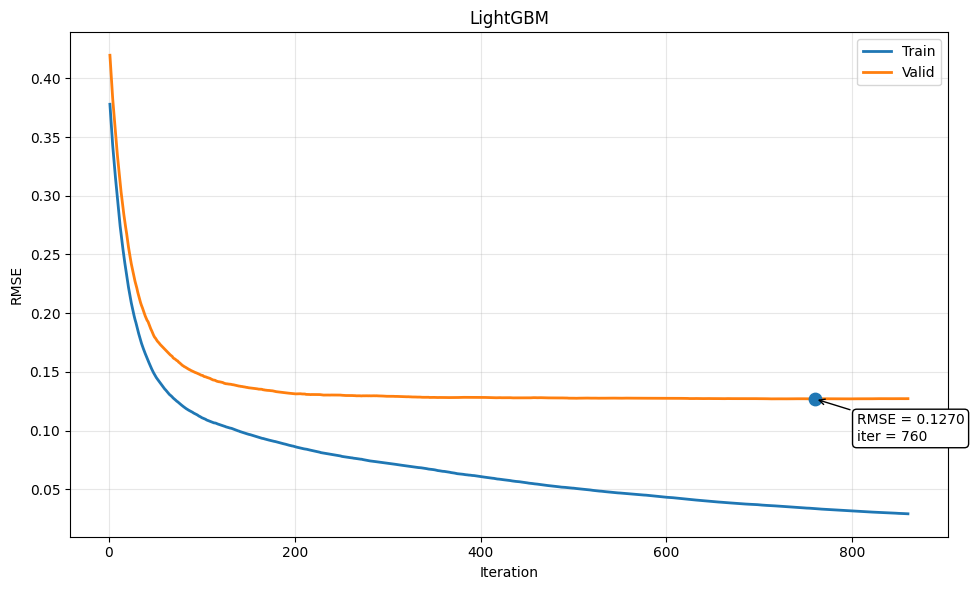

In [7]:
show_training_history(
    advanced_results["training_history"]["CatBoost"],
    model_name="LightGBM",
)

# Advanced модели: результаты и выводы

## Задача

Предсказать цену дома (`SalePrice`) на основе признаков.

---

## Результаты advanced моделей (log target)

| Model            | MAE     | RMSE     | R²        |
| ---------------- | ------- | -------- | --------- |
| CatBoost         | 0.0824  | **0.1275** | **0.9129** |
| GradientBoosting | 0.0865  | 0.1285   | 0.9115    |
| XGBoost          | 0.0860  | 0.1326   | 0.9057    |
| LightGBM         | 0.0947  | 0.1442   | 0.8885    |
| Bagging          | 0.0977  | 0.1469   | 0.8844    |
| ExtraTrees       | 0.0968  | 0.1471   | 0.8841    |
| RandomForest     | 0.0972  | 0.1473   | 0.8838    |

---

## Интерпретация

### 1. Сравнение с baseline

Лучшая baseline модель:

- Ridge
- RMSE ≈ 0.1299

Лучшая advanced модель:

- CatBoost
- RMSE ≈ 0.1275

Улучшение:

- небольшое, но стабильное
- модели бустинга всё ещё дают лучший результат

Это означает, что основная структура данных уже хорошо поймана baseline моделью
Advanced модели дают дополнительный прирост за счёт нелинейностей

---

### 2. Лучшая модель

Лучший результат показал:

- CatBoost
- RMSE ≈ 0.1275
- R² ≈ 0.913

CatBoost хорошо работает с категориальными и табличными данными
показывает наиболее стабильный результат среди бустингов

---

### 3. Как интерпретировать RMSE

RMSE ≈ 0.127 означает:

exp(0.127) ≈ 1.135

Ошибка модели ≈ 13–14%

То есть:

- если дом стоит 200 000
- ошибка ≈ ±26 000

---

### 4. R²

Для CatBoost:

R² ≈ 0.913

Модель объясняет примерно **91% вариации лог-цены**

Это высокий результат для табличной задачи

---

## Что показали графики обучения

По history бустингов видно:

- train error продолжает уменьшаться
- valid error быстро падает в начале
- затем выходит на плато

Это означает:

- модель эффективно учится
- основной прирост качества происходит на первых итерациях
- дальнейшее обучение даёт слабый прирост
- возможен риск переобучения при большом числе деревьев

---

## Выводы

- advanced модели немного улучшают baseline
- лучший результат показал **CatBoost**
- бустинг остаётся сильнейшим подходом для табличных данных
- прирост качества небольшой → задача уже хорошо решена линейными моделями
- текущий уровень ошибки ≈ **13–14%**, что является хорошим результатом